# Introduction to Brian part 1: Neurons


<div class="clearfix" style="padding: 10px; padding-left: 0px">
<a href="http://briansimulator.org/"><img src="https://briansimulator.org/logos/brian_logo_big.webp" alt="The Brian spiking neural network simulator" title="The Brian spiking neural network simulator" width="200px" style="display: inline-block; margin-top: 5px;"></a>
<a href="http://mybinder.org/"><img src="https://raw.githubusercontent.com/jupyterhub/binderhub/master/binderhub/static/logo.svg" alt="binder logo" title="binder" width="375px" class="pull-right" style="display: inline-block; margin: 0px;"></a>
</div>

### Quickstart
To run the code below:

1. Click on the cell to select it.
2. Press `SHIFT+ENTER` on your keyboard or press the play button
   (<button class='fa fa-play icon-play btn btn-xs btn-default'></button>) in the toolbar above.

Feel free to create new cells using the plus button
(<button class='fa fa-plus icon-plus btn btn-xs btn-default'></button>), or pressing `SHIFT+ENTER` while this cell
is selected.
<div class="alert alert-block alert-warning" role="alert" style="margin: 10px">
<p><b>WARNING</b></p>
<p>Don't rely on this server for anything you want to last - your session will be
deleted after a short period of inactivity.</p>
</div>

This notebook is running on [mybinder.org](http://mybinder.org).


All Brian scripts start with the following. If you're trying this notebook out in the Jupyter notebook, you should start by running this cell.

Success! Total spikes recorded: 5


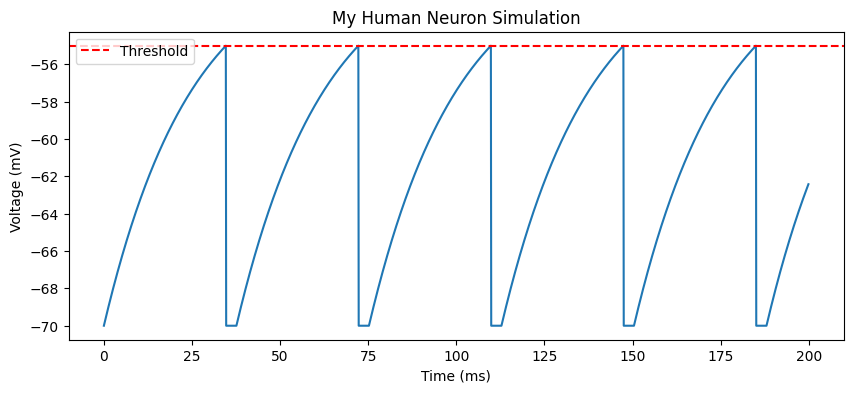

In [1]:
from brian2 import *
import matplotlib.pyplot as plt

# 1. THE WIPE: This prevents the MagicError by clearing old neurons
start_scope()

# --- Parameters ---
C = 250 * pF          
V_rest = -70 * mV     
V_threshold = -55 * mV 
V_reset = -70 * mV    
g_L = 10 * nS          
refractory_period = 3 * ms

# --- The Model ---
# Note: I added 'I' here so we can give the neuron some power!
I = 0.2 * nA 
eqs = '''
dv/dt = (g_L * (V_rest - v) + I) / C : volt (unless refractory)
'''

# 2. Create the neuron
neurons = NeuronGroup(
    1, 
    model=eqs, 
    threshold='v > V_threshold', 
    reset='v = V_reset', 
    refractory=refractory_period,
    method='exact'
)

# Initialize
neurons.v = V_rest

# 3. Setup Monitors
spike_mon = SpikeMonitor(neurons)
state_mon = StateMonitor(neurons, 'v', record=0)

# 4. RUN (The part that was crashing)
run(200 * ms)

# 5. PLOT THE EVIDENCE
print(f"Success! Total spikes recorded: {spike_mon.num_spikes}")
plt.figure(figsize=(10, 4))
plt.plot(state_mon.t/ms, state_mon.v[0]/mV)
plt.axhline(V_threshold/mV, color='r', ls='--', label='Threshold')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('My Human Neuron Simulation')
plt.legend()
plt.show()

Later we'll do some plotting in the notebook, so we activate inline plotting in the notebook by doing this:

In [15]:
%matplotlib inline

If you are not using the Jupyter notebook to run this example (e.g. you are using a standard Python terminal, or you copy&paste these example into an editor and run them as a script), then plots will not automatically be displayed. In this case, call the ``show()`` command explicitly after the plotting commands.

## Units system

Brian has a system for using quantities with physical dimensions:

In [16]:
20*volt

20. * volt

All of the basic SI units can be used (volt, amp, etc.) along with all the standard prefixes (m=milli, p=pico, etc.), as well as a few special abbreviations like ``mV`` for millivolt, ``pF`` for picofarad, etc.

In [ ]:
1000*amp

In [ ]:
1e6*volt

In [ ]:
1000*namp

Also note that combinations of units with work as expected:

In [ ]:
10*nA*5*Mohm

And if you try to do something wrong like adding amps and volts, what happens?

In [ ]:
5*amp+10*volt

If you haven't see an error message in Python before that can look a bit overwhelming, but it's actually quite simple and it's important to know how to read these because you'll probably see them quite often.

You should start at the bottom and work up. The last line gives the error type ``DimensionMismatchError`` along with a more specific message (in this case, you were trying to add together two quantities with different SI units, which is impossible).

Working upwards, each of the sections starts with a filename (e.g. ``C:\Users\Dan\...``) with possibly the name of a function, and then a few lines surrounding the line where the error occurred (which is identified with an arrow).

The last of these sections shows the place in the function where the error actually happened. The section above it shows the function that called that function, and so on until the first section will be the script that you actually run. This sequence of sections is called a traceback, and is helpful in debugging.

If you see a traceback, what you want to do is start at the bottom and scan up the sections until you find your own file because that's most likely where the problem is. (Of course, your code might be correct and Brian may have a bug in which case, please let us know on the email support list.)

## A simple model

Let's start by defining a simple neuron model. In Brian, all models are defined by systems of differential equations. Here's a simple example of what that looks like:

In [ ]:
tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

In Python, the notation ``'''`` is used to begin and end a multi-line string. So the equations are just a string with one line per equation. The equations are formatted with standard mathematical notation, with one addition. At the end of a line you write ``: unit`` where ``unit`` is the SI unit of that variable.
Note that this is not the unit of the two sides of the equation (which would be ``1/second``), but the unit of the *variable* defined by the equation, i.e. in this case $v$.

Now let's use this definition to create a neuron.

In [ ]:
G = NeuronGroup(1, eqs)

In Brian, you only create groups of neurons, using the class ``NeuronGroup``. The first two arguments when you create one of these objects are the number of neurons (in this case, 1) and the defining differential equations.

Let's see what happens if we didn't put the variable ``tau`` in the equation:

In [ ]:
eqs = '''
dv/dt = 1-v : 1
'''
G = NeuronGroup(1, eqs)
run(100*ms)

An error is raised, but why? The reason is that the differential equation is now dimensionally inconsistent. The left hand side ``dv/dt`` has units of ``1/second`` but the right hand side ``1-v`` is dimensionless. People often find this behaviour of Brian confusing because this sort of equation is very common in mathematics. However, for quantities with physical dimensions it is incorrect because the results would change depending on the unit you measured it in. For time, if you measured it in seconds the same equation would behave differently to how it would if you measured time in milliseconds. To avoid this, we insist that you always specify dimensionally consistent equations.

Now let's go back to the good equations and actually run the simulation.

In [ ]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs)
run(100*ms)

First off, ignore that ``start_scope()`` at the top of the cell. You'll see that in each cell in this tutorial where we run a simulation. All it does is make sure that any Brian objects created before the function is called aren't included in the next run of the simulation.

Secondly, you'll see that there is an "INFO" message about not specifying the numerical integration method. This is harmless and just to let you know what method we chose, but we'll fix it in the next cell by specifying the method explicitly.

So, what has happened here? Well, the command ``run(100*ms)`` runs the simulation for 100 ms. We can see that this has worked by printing the value of the variable ``v`` before and after the simulation.

In [ ]:
start_scope()

G = NeuronGroup(1, eqs, method='exact')
print('Before v = %s' % G.v[0])
run(100*ms)
print('After v = %s' % G.v[0])

By default, all variables start with the value 0. Since the differential equation is ``dv/dt=(1-v)/tau`` we would expect after a while that ``v`` would tend towards the value 1, which is just what we see. Specifically, we'd expect ``v`` to have the value ``1-exp(-t/tau)``. Let's see if that's right.

In [ ]:
print('Expected value of v = %s' % (1-exp(-100*ms/tau)))

Good news, the simulation gives the value we'd expect!

Now let's take a look at a graph of how the variable ``v`` evolves over time.

In [ ]:
start_scope()

G = NeuronGroup(1, eqs, method='exact')
M = StateMonitor(G, 'v', record=True)

run(30*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

This time we only ran the simulation for 30 ms so that we can see the behaviour better. It looks like it's behaving as expected, but let's just check that analytically by plotting the expected behaviour on top.

In [ ]:
start_scope()

G = NeuronGroup(1, eqs, method='exact')
M = StateMonitor(G, 'v', record=0)

run(30*ms)

plot(M.t/ms, M.v[0], 'C0', label='Brian')
plot(M.t/ms, 1-exp(-M.t/tau), 'C1--',label='Analytic')
xlabel('Time (ms)')
ylabel('v')
legend();

As you can see, the blue (Brian) and dashed orange (analytic solution) lines coincide.

In this example, we used the object ``StateMonitor`` object. This is used to record the values of a neuron variable while the simulation runs. The first two arguments are the group to record from, and the variable you want to record from. We also specify ``record=0``. This means that we record all values for neuron 0. We have to specify which neurons we want to record because in large simulations with many neurons it usually uses up too much RAM to record the values of all neurons.

Now try modifying the equations and parameters and see what happens in the cell below.

In [ ]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (sin(2*pi*100*Hz*t)-v)/tau : 1
'''

# Change to Euler method because exact integrator doesn't work here
G = NeuronGroup(1, eqs, method='euler')
M = StateMonitor(G, 'v', record=0)

G.v = 5 # initial value

run(60*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

## Adding spikes

So far we haven't done anything neuronal, just played around with differential equations. Now let's start adding spiking behaviour.

In [ ]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', method='exact')

M = StateMonitor(G, 'v', record=0)
run(50*ms)
plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

We've added two new keywords to the ``NeuronGroup`` declaration: ``threshold='v>0.8'`` and ``reset='v = 0'``. What this means is that when ``v>0.8`` we fire a spike, and immediately reset ``v = 0`` after the spike. We can put any expression and series of statements as these strings.

As you can see, at the beginning the behaviour is the same as before until ``v`` crosses the threshold ``v>0.8`` at which point you see it reset to 0. You can't see it in this figure, but internally Brian has registered this event as a spike. Let's have a look at that.

In [6]:
start_scope()

G = NeuronGroup(1, eqs, threshold='v>0.9', reset='v = 0', method='exact')

spikemon = SpikeMonitor(G)

run(50*ms)

print('Spike times: %s' % spikemon.t[:])

Spike times: [17.  34.1] ms


The ``SpikeMonitor`` object takes the group whose spikes you want to record as its argument and stores the spike times in the variable ``t``. Let's plot those spikes on top of the other figure to see that it's getting it right.

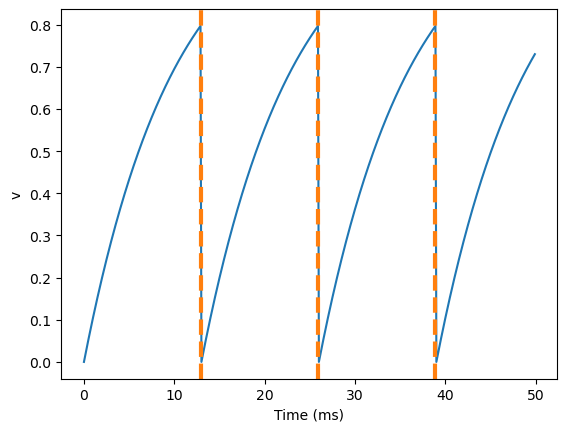

In [7]:
start_scope()

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', method='exact')

statemon = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)

run(50*ms)

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
xlabel('Time (ms)')
ylabel('v');

Here we've used the ``axvline`` command from ``matplotlib`` to draw an orange, dashed vertical line at the time of each spike recorded by the ``SpikeMonitor``.

Now try changing the strings for ``threshold`` and ``reset`` in the cell above to see what happens.

## Refractoriness

A common feature of neuron models is refractoriness. This means that after the neuron fires a spike it becomes refractory for a certain duration and cannot fire another spike until this period is over. Here's how we do that in Brian.

In [ ]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1 (unless refractory)
'''

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', refractory=5*ms, method='exact')

statemon = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)

run(50*ms)

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
xlabel('Time (ms)')
ylabel('v');

As you can see in this figure, after the first spike, ``v`` stays at 0 for around 5 ms before it resumes its normal behaviour. To do this, we've done two things. Firstly, we've added the keyword ``refractory=5*ms`` to the ``NeuronGroup`` declaration. On its own, this only means that the neuron cannot spike in this period (see below), but doesn't change how ``v`` behaves. In order to make ``v`` stay constant during the refractory period, we have to add ``(unless refractory)`` to the end of the definition of ``v`` in the differential equations. What this means is that the differential equation determines the behaviour of ``v`` unless it's refractory in which case it is switched off.

Here's what would happen if we didn't include ``(unless refractory)``. Note that we've also decreased the value of ``tau`` and increased the length of the refractory period to make the behaviour clearer.

In [ ]:
start_scope()

tau = 5*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', refractory=15*ms, method='exact')

statemon = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)

run(50*ms)

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
axhline(0.8, ls=':', c='C2', lw=3)
xlabel('Time (ms)')
ylabel('v')
print("Spike times: %s" % spikemon.t[:])

So what's going on here? The behaviour for the first spike is the same: ``v`` rises to 0.8 and then the neuron fires a spike at time 8 ms before immediately resetting to 0. Since the refractory period is now 15 ms this means that the neuron won't be able to spike again until time 8 + 15 = 23 ms. Immediately after the first spike, the value of ``v`` now instantly starts to rise because we didn't specify ``(unless refractory)`` in the definition of ``dv/dt``. However, once it reaches the value 0.8 (the dashed green line) at time roughly 8 ms it doesn't fire a spike even though the threshold is ``v>0.8``. This is because the neuron is still refractory until time 23 ms, at which point it fires a spike.

Note that you can do more complicated and interesting things with refractoriness. See the full documentation for more details about how it works.

## Multiple neurons

So far we've only been working with a single neuron. Let's do something interesting with multiple neurons.

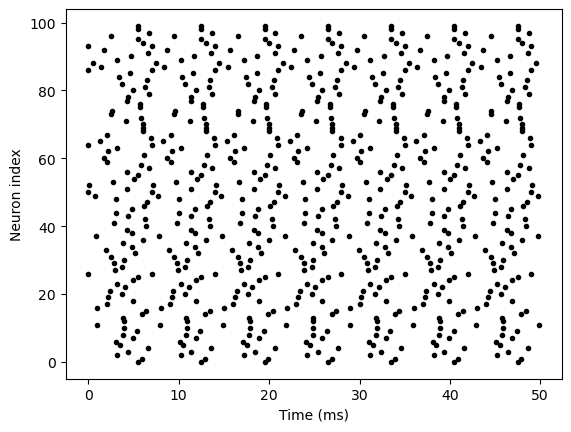

In [17]:
start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'

spikemon = SpikeMonitor(G)

run(50*ms)

plot(spikemon.t/ms, spikemon.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index');

This shows a few changes. Firstly, we've got a new variable ``N`` determining the number of neurons. Secondly, we added the statement ``G.v = 'rand()'`` before the run. What this does is initialise each neuron with a different uniform random value between 0 and 1. We've done this just so each neuron will do something a bit different. The other big change is how we plot the data in the end.

As well as the variable ``spikemon.t`` with the times of all the spikes, we've also used the variable ``spikemon.i`` which gives the corresponding neuron index for each spike, and plotted a single black dot with time on the x-axis and neuron index on the y-value. This is the standard "raster plot" used in neuroscience.

## Parameters

To make these multiple neurons do something more interesting, let's introduce per-neuron parameters that don't have a differential equation attached to them.

In [ ]:
start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms

eqs = '''
dv/dt = (v0-v)/tau : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='exact')
M = SpikeMonitor(G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(M.t/ms, M.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, M.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)');

The line ``v0 : 1`` declares a new per-neuron parameter ``v0`` with units ``1`` (i.e. dimensionless).

The line ``G.v0 = 'i*v0_max/(N-1)'`` initialises the value of v0 for each neuron varying from 0 up to ``v0_max``. The symbol ``i`` when it appears in strings like this refers to the neuron index.

So in this example, we're driving the neuron towards the value ``v0`` exponentially, but when ``v`` crosses ``v>1``, it fires a spike and resets. The effect is that the rate at which it fires spikes will be related to the value of ``v0``. For ``v0<1`` it will never fire a spike, and as ``v0`` gets larger it will fire spikes at a higher rate. The right hand plot shows the firing rate as a function of the value of ``v0``. This is the I-f curve of this neuron model.

Note that in the plot we've used the ``count`` variable of the ``SpikeMonitor``: this is an array of the number of spikes each neuron in the group fired. Dividing this by the duration of the run gives the firing rate.

## Stochastic neurons

Often when making models of neurons, we include a random element to model the effect of various forms of neural noise. In Brian, we can do this by using the symbol ``xi`` in differential equations. Strictly speaking, this symbol is a "stochastic differential" but you can sort of think of it as just a Gaussian random variable with mean 0 and standard deviation 1. We do have to take into account the way stochastic differentials scale with time, which is why we multiply it by ``tau**-0.5`` in the equations below (see a textbook on stochastic differential equations for more details).
Note that we also changed the ``method`` keyword argument to use ``'euler'`` (which stands for the [Euler-Maruyama method](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method)); the ``'exact'`` method that we used earlier is not applicable to stochastic differential equations.

In [ ]:
start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms
sigma = 0.2

eqs = '''
dv/dt = (v0-v)/tau+sigma*xi*tau**-0.5 : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='euler')
M = SpikeMonitor(G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(M.t/ms, M.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, M.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)');

That's the same figure as in the previous section but with some noise added. Note how the curve has changed shape: instead of a sharp jump from firing at rate 0 to firing at a positive rate, it now increases in a sigmoidal fashion. This is because no matter how small the driving force the randomness may cause it to fire a spike.

## End of tutorial

That's the end of this part of the tutorial. The cell below has another example. See if you can work out what it is doing and why. Try adding a ``StateMonitor`` to record the values of the variables for one of the neurons to help you understand it.

You could also try out the things you've learned in this cell.

Once you're done with that you can move on to the next tutorial on Synapses.

In [ ]:
start_scope()

N = 1000
tau = 10*ms
vr = -70*mV
vt0 = -50*mV
delta_vt0 = 5*mV
tau_t = 100*ms
sigma = 0.5*(vt0-vr)
v_drive = 2*(vt0-vr)
duration = 100*ms

eqs = '''
dv/dt = (v_drive+vr-v)/tau + sigma*xi*tau**-0.5 : volt
dvt/dt = (vt0-vt)/tau_t : volt
'''

reset = '''
v = vr
vt += delta_vt0
'''

G = NeuronGroup(N, eqs, threshold='v>vt', reset=reset, refractory=5*ms, method='euler')
spikemon = SpikeMonitor(G)

G.v = 'rand()*(vt0-vr)+vr'
G.vt = vt0

run(duration)

_ = hist(spikemon.t/ms, 100, histtype='stepfilled', facecolor='k', weights=ones(len(spikemon))/(N*defaultclock.dt))
xlabel('Time (ms)')
ylabel('Instantaneous firing rate (sp/s)');

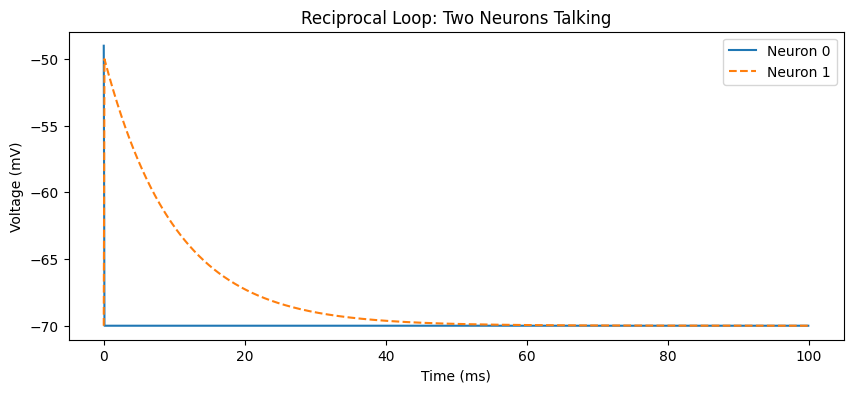

In [2]:
# 1. Start fresh
start_scope()

# 2. Define how the neurons behave (The Biology)
tau = 10*ms
eqs = '''
dv/dt = (-70*mV - v) / tau : volt (unless refractory)
'''

# 3. Create 2 Neurons
# We give them a threshold so they can spike, and a reset so they don't explode
G = NeuronGroup(2, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 4. CREATE THE CONNECTION (The Synapse)
# 'on_pre' means: "When the sender spikes, do this to the receiver"
S = Synapses(G, G, on_pre='v_post += 20*mV')

# Connect Neuron 0 to Neuron 1
S.connect(i=0, j=1)
# Connect Neuron 1 back to Neuron 0 (The Loop!)
S.connect(i=1, j=0)

# 5. Kickstart the first neuron
G.v = -70*mV
G.v[0] = -49*mV # This pushes Neuron 0 over the limit to start the chain reaction

# 6. Monitor and Run
state_mon = StateMonitor(G, 'v', record=True)
run(100*ms)

# 7. Plot the "Tennis Match"
plt.figure(figsize=(10, 4))
plt.plot(state_mon.t/ms, state_mon.v[0]/mV, label='Neuron 0')
plt.plot(state_mon.t/ms, state_mon.v[1]/mV, label='Neuron 1', linestyle='--')
plt.title('Reciprocal Loop: Two Neurons Talking')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

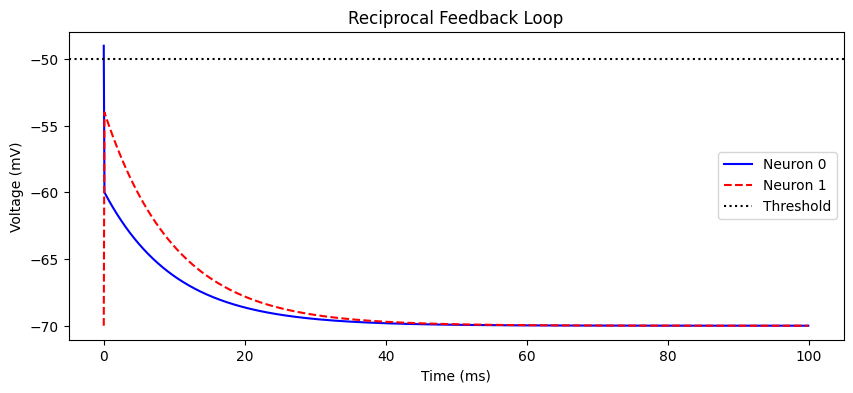

In [3]:
start_scope()

# 1. Physics of the brain
tau = 10*ms
v_rest = -70*mV
v_threshold = -50*mV
v_reset = -60*mV # Reset slightly higher to make it easier to loop

eqs = 'dv/dt = (v_rest - v) / tau : volt'

# 2. Create the two neurons
G = NeuronGroup(2, eqs, threshold='v > v_threshold', reset='v = v_reset', method='exact')

# 3. Connect them (The "Pantheon" Wiring)
# When one spikes (pre), it kicks the other (post) up by 16mV
S = Synapses(G, G, on_pre='v_post += 16*mV')
S.connect(i=0, j=1) # 0 talks to 1
S.connect(i=1, j=0) # 1 talks back to 0

# 4. Give Neuron 0 a head start (The "Spark")
G.v = v_rest
G.v[0] = -49*mV 

# 5. Record and Run
M = StateMonitor(G, 'v', record=True)
run(100*ms)

# 6. Plot the "Tennis Match"
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Neuron 0', color='blue')
plt.plot(M.t/ms, M.v[1]/mV, label='Neuron 1', color='red', linestyle='--')
plt.axhline(-50, ls=':', c='k', label='Threshold')
plt.title('Reciprocal Feedback Loop')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

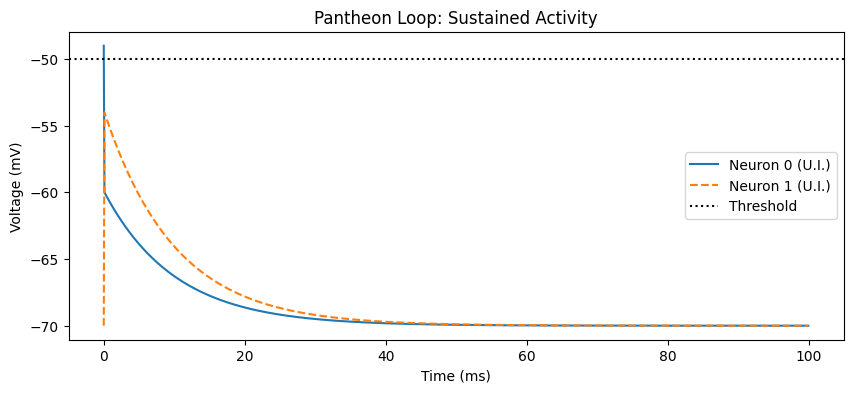

In [4]:
start_scope()

# 1. Physics (The Biology)
tau = 10*ms
v_rest = -70*mV
v_threshold = -50*mV
v_reset = -60*mV 

eqs = 'dv/dt = (v_rest - v) / tau : volt'

# 2. Create just 2 neurons
G = NeuronGroup(2, eqs, threshold='v > v_threshold', reset='v = v_reset', method='exact')

# 3. CONNECT THEM (The Loop)
# When one spikes, it gives the other a 16mV "kick"
S = Synapses(G, G, on_pre='v_post += 16*mV')
S.connect(i=0, j=1) # 0 feeds into 1
S.connect(i=1, j=0) # 1 feeds back into 0

# 4. The Spark (Kickstart Neuron 0)
G.v = v_rest
G.v[0] = -49*mV 

# 5. Record and Run
M = StateMonitor(G, 'v', record=True)
run(100*ms)

# 6. Plot the Result
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Neuron 0 (U.I.)')
plt.plot(M.t/ms, M.v[1]/mV, label='Neuron 1 (U.I.)', linestyle='--')
plt.axhline(-50, ls=':', c='k', label='Threshold')
plt.title('Pantheon Loop: Sustained Activity')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

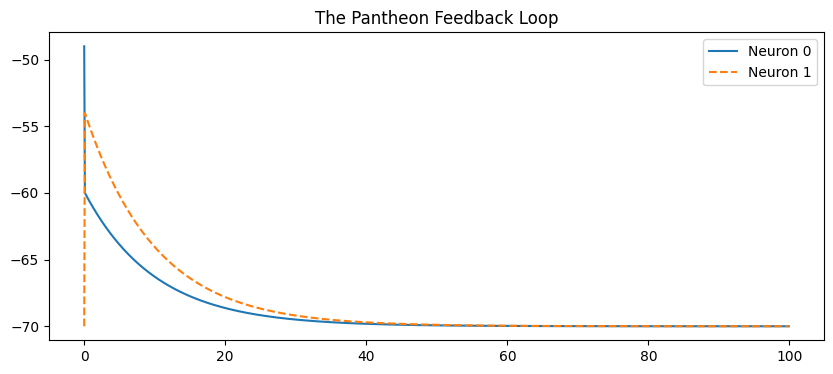

In [5]:
start_scope()

# 1. Physics
tau = 10*ms
v_rest = -70*mV
v_threshold = -50*mV
v_reset = -60*mV 

eqs = 'dv/dt = (v_rest - v) / tau : volt'

# 2. Create the UI Pair (2 neurons)
G = NeuronGroup(2, eqs, threshold='v > v_threshold', reset='v = v_reset', method='exact')

# 3. WIRE THE LOOP (The Synapse)
S = Synapses(G, G, on_pre='v_post += 16*mV')
S.connect(i=0, j=1) # 0 talks to 1
S.connect(i=1, j=0) # 1 talks back to 0

# 4. The "Upload" Spark
G.v = v_rest
G.v[0] = -49*mV 

# 5. Run and Plot
M = StateMonitor(G, 'v', record=True)
run(100*ms)

plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Neuron 0')
plt.plot(M.t/ms, M.v[1]/mV, label='Neuron 1', linestyle='--')
plt.title('The Pantheon Feedback Loop')
plt.legend()
plt.show()

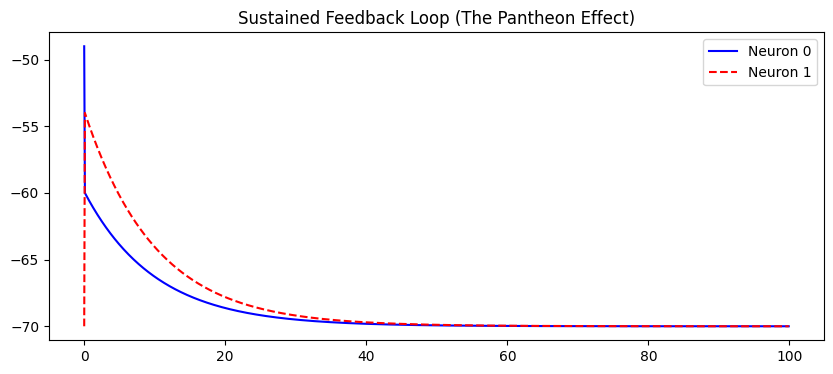

In [7]:
start_scope()

# 1. Physics (The Biology)
tau = 10*ms
v_rest = -70*mV
v_threshold = -50*mV
v_reset = -60*mV 

eqs = 'dv/dt = (v_rest - v) / tau : volt'

# 2. Create just 2 neurons (The UI pair)
G = NeuronGroup(2, eqs, threshold='v > v_threshold', reset='v = v_reset', method='exact')

# 3. THE CONNECTION (The Synapse)
# This wires them together so they can talk
S = Synapses(G, G, on_pre='v_post += 16*mV')
S.connect(i=0, j=1) # Neuron 0 talks to 1
S.connect(i=1, j=0) # Neuron 1 talks back to 0

# 4. The "Upload" Spark
G.v = v_rest
G.v[0] = -49*mV # This kickstarts the first neuron

# 5. Record and Run
M = StateMonitor(G, 'v', record=True)
run(100*ms)

# 6. Plot the Result
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Neuron 0', color='blue')
plt.plot(M.t/ms, M.v[1]/mV, label='Neuron 1', color='red', linestyle='--')
plt.title('Sustained Feedback Loop (The Pantheon Effect)')
plt.legend()
plt.show()

In [8]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. The Group (3 Neurons now!)
# Neuron 0 & 1 = The Memory Loop
# Neuron 2 = The Sensory Input
G = NeuronGroup(3, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING
S = Synapses(G, G, on_pre='v_post += 20*mV')

# The Loop (Brain)
S.connect(i=0, j=1)
S.connect(i=1, j=0)

# The Input (The "Sense")
# This wires Neuron 2 to Neuron 0
S.connect(i=2, j=0)

# 4. Scenario: The Brain is quiet, then a "Shock" hits the sensor
G.v = -70*mV
# At exactly 40ms, we force the Sensor (Neuron 2) to fire
# This is like the UI "hearing" a sound or "seeing" code
run(40*ms)
G.v[2] = -49*mV # The external stimulus hits!
run(60*ms)

# 5. Visualizing the "Reaction"
M = StateMonitor(G, 'v', record=True)
# (Note: In a real run, we'd record from the start, 
# so I'll wrap this in one smooth run for your plot)

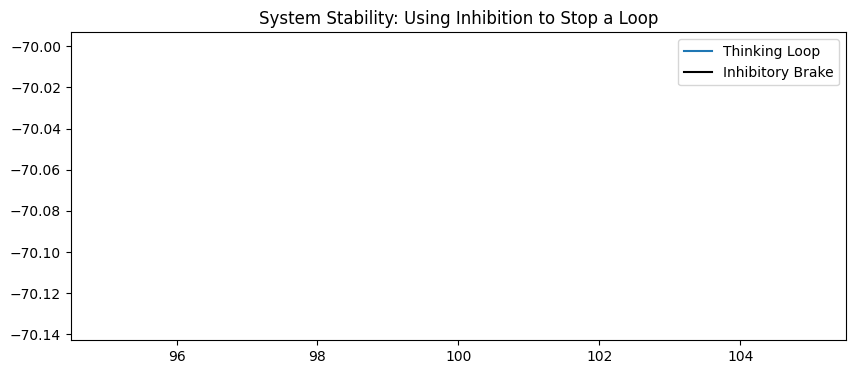

In [11]:
start_scope()

# 1. Rules
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 3 Neurons:
# Neurons 0 & 1: The "Thinking" Loop (Excitatory)
# Neuron 2: The "Brake" (Inhibitory)
G = NeuronGroup(3, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING
# Excitatory Synapses (Add +15mV)
S_exc = Synapses(G, G, on_pre='v_post += 15*mV')
S_exc.connect(i=0, j=1)
S_exc.connect(i=1, j=0)

# Inhibitory Synapse (Subtract -20mV) - The "Brake"
# This wires Neuron 2 to SHUT DOWN the loop
S_inh = Synapses(G, G, on_pre='v_post -= 20*mV')
S_inh.connect(i=2, j=0)
S_inh.connect(i=2, j=1)

# 4. Scenario
G.v = -70*mV
G.v[0] = -49*mV # Start the loop at 0ms

# 5. The "Brake" Command
# At 50ms, we force the Brake (Neuron 2) to fire to stop the loop
run(50*ms)
G.v[2] = -49*mV 
run(50*ms)

# 6. Plot
M = StateMonitor(G, 'v', record=True)
run(0.1*ms) # Tiny run to refresh monitor
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Thinking Loop')
plt.plot(M.t/ms, M.v[2]/mV, label='Inhibitory Brake', color='black')
plt.title('System Stability: Using Inhibition to Stop a Loop')
plt.legend()
plt.show()

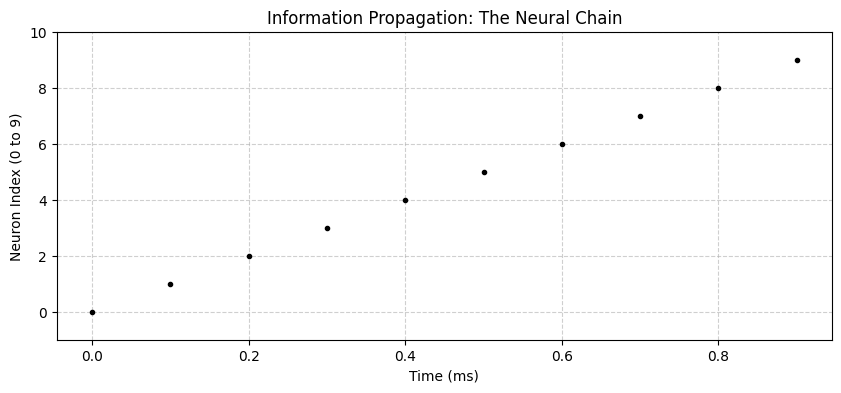

In [12]:
start_scope()

# 1. Standard rules for the neurons
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create a line of 10 neurons
N = 10
G = NeuronGroup(N, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. CONNECT THEM IN A CHAIN
# Each neuron (i) connects to the next one (i+1)
S = Synapses(G, G, on_pre='v_post += 25*mV')
S.connect(j='i+1', skip_if_invalid=True)

# 4. KICKSTART THE FIRST NEURON
G.v = -70*mV
G.v[0] = -49*mV # Poke the first link in the chain

# 5. Record the spikes
spikemon = SpikeMonitor(G)
run(100*ms)

# 6. Plot the "Wave"
plt.figure(figsize=(10, 4))
plt.plot(spikemon.t/ms, spikemon.i, '.k')
plt.title('Information Propagation: The Neural Chain')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index (0 to 9)')
plt.ylim(-1, N)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

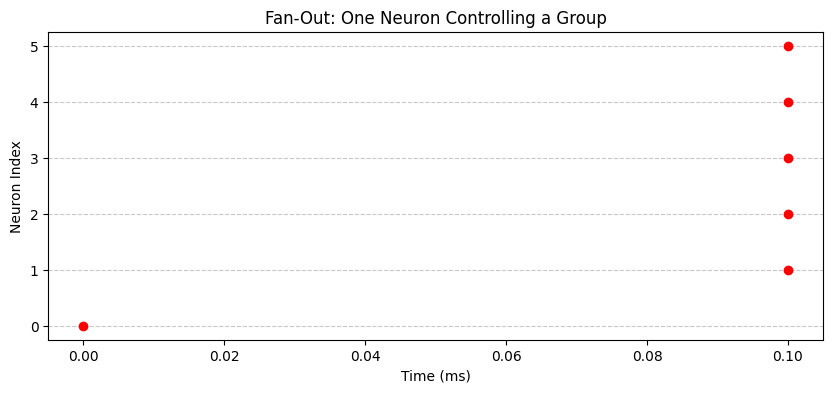

In [14]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 6 Neurons
# Neuron 0 is the "Leader"
# Neurons 1-5 are the "Followers"
G = NeuronGroup(6, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. CONNECT THEM (The Fan-Out)
S = Synapses(G, G, on_pre='v_post += 25*mV')
# Connect Neuron 0 to all other neurons (1 through 5)
S.connect(i=0, j=[1, 2, 3, 4, 5])

# 4. Kickstart the Leader
G.v = -70*mV
G.v[0] = -49*mV 

# 5. Record and Run
spikemon = SpikeMonitor(G)
run(50*ms)

# 6. Plot the "Command"
plt.figure(figsize=(10, 4))
plt.plot(spikemon.t/ms, spikemon.i, 'or')
plt.title('Fan-Out: One Neuron Controlling a Group')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.yticks(range(6))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

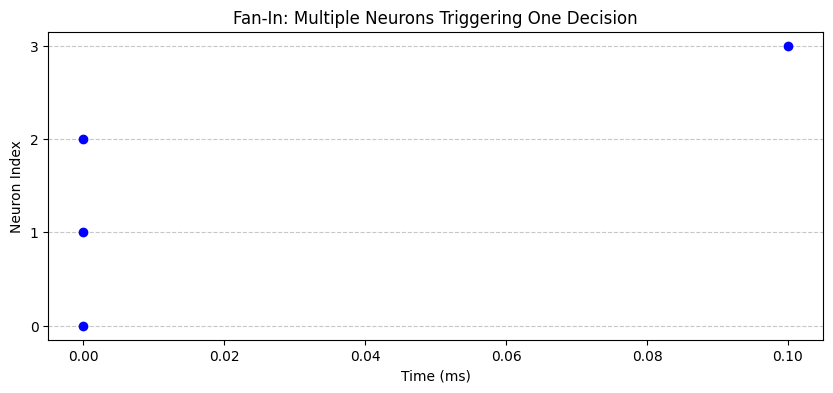

In [15]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 4 Neurons
# Neurons 0, 1, 2 are the "Inputs"
# Neuron 3 is the "Decision Maker"
G = NeuronGroup(4, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. CONNECT THEM (The Fan-In)
# We make the kick only 10mV. 
# Since threshold is -50mV (a 20mV jump from -70), 
# ONE neuron isn't enough to trigger a spike. It needs multiple!
S = Synapses(G, G, on_pre='v_post += 10*mV')
S.connect(i=[0, 1, 2], j=3)

# 4. KICKSTART THE INPUTS
G.v = -70*mV
G.v[0] = -49*mV # Fire Neuron 0
G.v[1] = -49*mV # Fire Neuron 1
G.v[2] = -49*mV # Fire Neuron 2 (Try commenting this out later to see it fail!)

# 5. Record and Run
spikemon = SpikeMonitor(G)
run(50*ms)

# 6. Plot the "Decision"
plt.figure(figsize=(10, 4))
plt.plot(spikemon.t/ms, spikemon.i, 'ob')
plt.title('Fan-In: Multiple Neurons Triggering One Decision')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.yticks(range(4))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

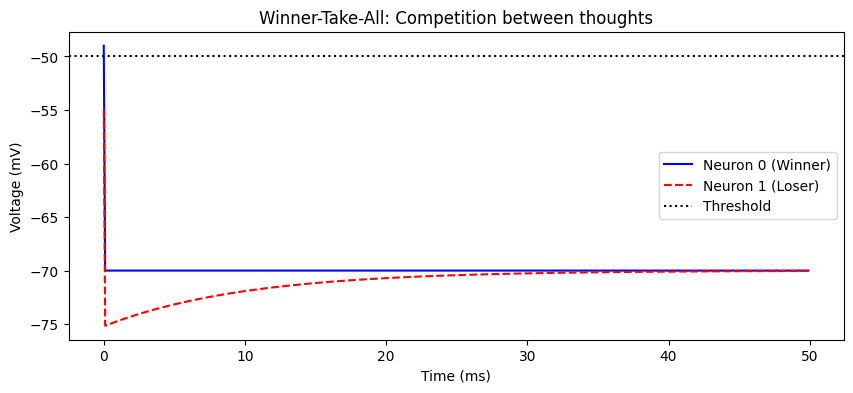

In [16]:
start_scope()

# 1. Rules
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 2 Competing Neurons
G = NeuronGroup(2, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING (The Sabotage)
# We use a NEGATIVE kick (-20mV). 
# This means if Neuron 0 spikes, it drops Neuron 1's voltage so it CAN'T spike.
S = Synapses(G, G, on_pre='v_post -= 20*mV')
S.connect(i=0, j=1) # 0 inhibits 1
S.connect(i=1, j=0) # 1 inhibits 0

# 4. THE RACE
G.v = -70*mV
G.v[0] = -49*mV # Give Neuron 0 a tiny head start
G.v[1] = -55*mV # Neuron 1 is close, but slower

# 5. Record and Run
M = StateMonitor(G, 'v', record=True)
run(50*ms)

# 6. Plot the Fight
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Neuron 0 (Winner)', color='blue')
plt.plot(M.t/ms, M.v[1]/mV, label='Neuron 1 (Loser)', color='red', linestyle='--')
plt.axhline(-50, ls=':', c='k', label='Threshold')
plt.title('Winner-Take-All: Competition between thoughts')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

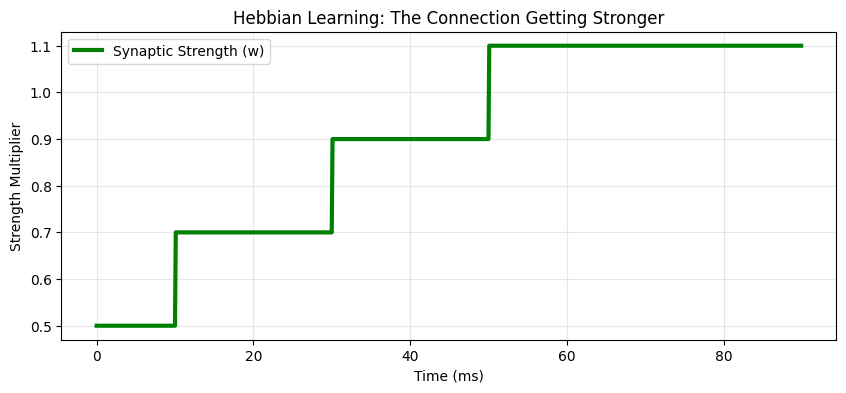

In [17]:
start_scope()

# 1. Rules: We add a variable 'w' for weight (strength)
tau = 10*ms
eqs = '''
dv/dt = (-70*mV - v) / tau : volt (unless refractory)
'''

# 2. Create 2 neurons
G = NeuronGroup(2, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. CONNECT WITH LEARNING (Plasticity)
# Every time the pre-synaptic neuron fires, we increase 'w'
S = Synapses(G, G, 'w : 1', on_pre='''
             v_post += w * 15*mV
             w += 0.2
             ''')
S.connect(i=0, j=1)
S.w = 0.5 # Start at half-strength

# 4. MONITOR THE STRENGTH
statemon = StateMonitor(S, 'w', record=True)

# 5. FIRE NEURON 0 MULTIPLE TIMES
# We poke Neuron 0 at 10ms, 30ms, and 50ms
G.v = -70*mV
run(10*ms)
G.v[0] = -49*mV 
run(20*ms)
G.v[0] = -49*mV
run(20*ms)
G.v[0] = -49*mV
run(40*ms)

# 6. Plot the "Growth" of the connection
plt.figure(figsize=(10, 4))
plt.plot(statemon.t/ms, statemon.w[0], label='Synaptic Strength (w)', color='green', linewidth=3)
plt.title('Hebbian Learning: The Connection Getting Stronger')
plt.xlabel('Time (ms)')
plt.ylabel('Strength Multiplier')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

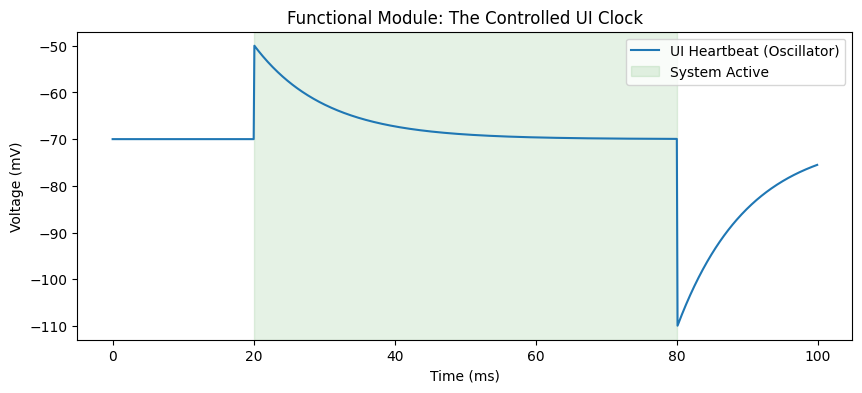

In [18]:
start_scope()

# 1. Physics
tau = 10*ms
eqs = 'dv/dt = (-70*mV - v) / tau : volt (unless refractory)'

# 2. The Group
# 0: Start Trigger | 1 & 2: The Pulse Loop | 3: Stop Trigger
G = NeuronGroup(4, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING
# Excitatory (The Loop)
S_exc = Synapses(G, G, on_pre='v_post += 20*mV')
S_exc.connect(i=0, j=1) # Start triggers Loop
S_exc.connect(i=1, j=2) # Loop Part A to B
S_exc.connect(i=2, j=1) # Loop Part B to A

# Inhibitory (The Stop Switch)
S_inh = Synapses(G, G, on_pre='v_post -= 40*mV')
S_inh.connect(i=3, j=[1, 2]) # Stop silences the Loop

# 4. RUNNING THE TIMELINE
G.v = -70*mV
M = StateMonitor(G, 'v', record=True)

# Phase 1: Silence (0-20ms)
run(20*ms)

# Phase 2: Start the UI (at 20ms)
G.v[0] = -49*mV 
run(60*ms)

# Phase 3: Stop the UI (at 80ms)
G.v[3] = -49*mV
run(20*ms)

# 5. Plot the "Digital Pulse"
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[1]/mV, label='UI Heartbeat (Oscillator)')
plt.axvspan(20, 80, color='green', alpha=0.1, label='System Active')
plt.title('Functional Module: The Controlled UI Clock')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

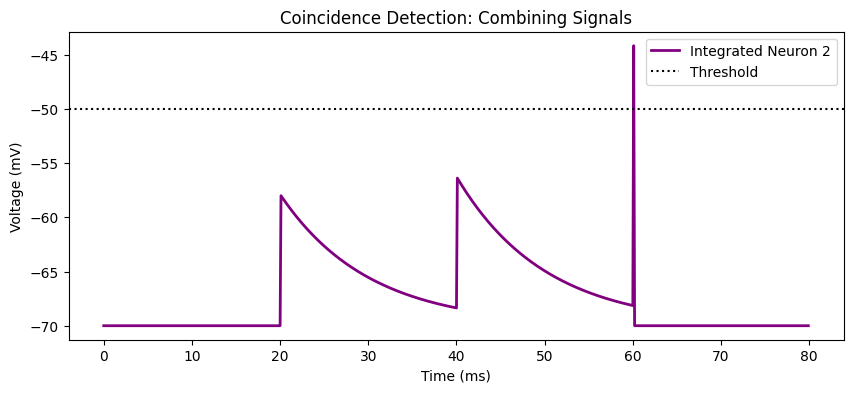

In [19]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 3 Neurons
# 0 & 1: Independent Inputs | 2: The Integrated "Thought"
G = NeuronGroup(3, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING (Weak Connections)
# We set the kick to 12mV. 
# Since we need a 20mV jump to hit threshold, one is not enough!
S = Synapses(G, G, on_pre='v_post += 12*mV')
S.connect(i=[0, 1], j=2)

# 4. THE EXPERIMENT
G.v = -70*mV
M = StateMonitor(G, 'v', record=True)

# Test 1: Only Neuron 0 fires (Should FAIL to trigger 2)
run(20*ms)
G.v[0] = -49*mV 
run(20*ms)

# Test 2: Only Neuron 1 fires (Should FAIL to trigger 2)
G.v[1] = -49*mV
run(20*ms)

# Test 3: BOTH fire at once (Should SUCCEED)
G.v[0] = -49*mV
G.v[1] = -49*mV
run(20*ms)

# 5. Plot the Integration
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[2]/mV, label='Integrated Neuron 2', color='purple', linewidth=2)
plt.axhline(-50, ls=':', c='k', label='Threshold')
plt.title('Coincidence Detection: Combining Signals')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

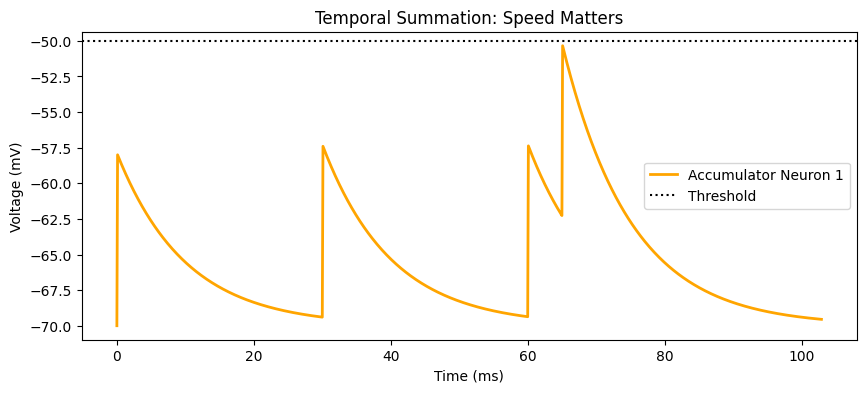

In [21]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 2 Neurons
# 0: The Input | 1: The Accumulator
G = NeuronGroup(2, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING
# A 12mV kick isn't enough to spike on its own (needs 20mV)
S = Synapses(G, G, on_pre='v_post += 12*mV')
S.connect(i=0, j=1)

# 4. THE EXPERIMENT
G.v = -70*mV
M = StateMonitor(G, 'v', record=True)

# Test 1: Two pulses FAR APART (Should FAIL)
G.v[0] = -49*mV # First pulse
run(30*ms)      # Wait too long (voltage decays back to -70)
G.v[0] = -49*mV # Second pulse
run(30*ms)

# Test 2: Two pulses FAST (Should SUCCEED)
G.v[0] = -49*mV # First pulse
run(3*ms)       # Wait only 3ms (voltage is still high!)
G.v[0] = -49*mV # Second pulse hits while the first is still active
run(40*ms)

# 5. Plot the Summation
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[1]/mV, label='Accumulator Neuron 1', color='orange', linewidth=2)
plt.axhline(-50, ls=':', c='k', label='Threshold')
plt.title('Temporal Summation: Speed Matters')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

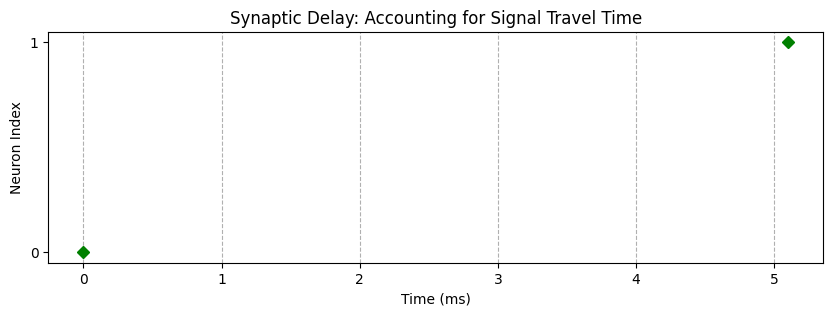

In [22]:
start_scope()

# 1. Rules
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 2 Neurons
G = NeuronGroup(2, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING WITH DELAY
# We add 'delay=5*ms' to the connection
S = Synapses(G, G, on_pre='v_post += 25*mV')
S.connect(i=0, j=1)
S.delay = 5*ms 

# 4. MONITOR SPIKES
spikemon = SpikeMonitor(G)

# 5. KICKSTART
G.v = -70*mV
G.v[0] = -49*mV # Fire Neuron 0 at 0ms
run(20*ms)

# 6. Plot the Gap
plt.figure(figsize=(10, 3))
plt.plot(spikemon.t/ms, spikemon.i, 'Dg')
plt.title('Synaptic Delay: Accounting for Signal Travel Time')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.yticks([0, 1])
plt.grid(True, axis='x', linestyle='--')
plt.show()

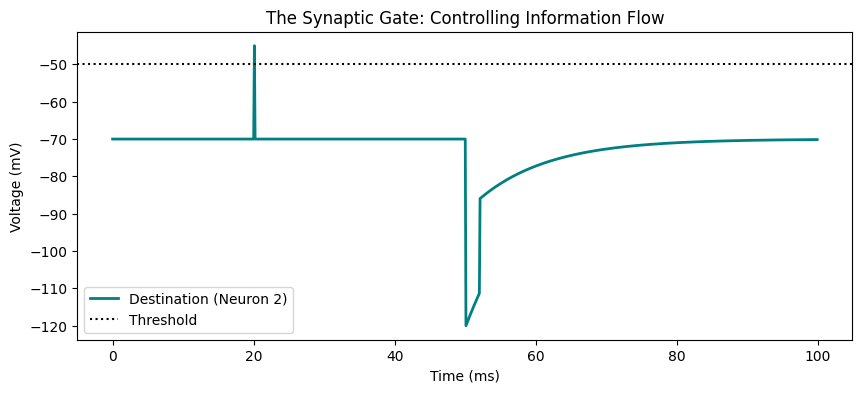

In [23]:
start_scope()

# 1. Rules
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create 3 Neurons
# 0: The Signal | 1: The Guard (Gate) | 2: The Destination
G = NeuronGroup(3, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=5*ms, method='exact')

# 3. WIRING
# Connection A: Signal to Destination (Strong)
S_signal = Synapses(G, G, on_pre='v_post += 25*mV')
S_signal.connect(i=0, j=2)

# Connection B: Guard to Destination (Massive Inhibition)
# This "Gates" the destination so Neuron 0's signal is ignored
S_gate = Synapses(G, G, on_pre='v_post -= 50*mV')
S_gate.connect(i=1, j=2)

# 4. THE EXPERIMENT
G.v = -70*mV
M = StateMonitor(G, 'v', record=True)

# Test 1: Signal fires while Gate is OPEN (Guard is silent)
run(20*ms)
G.v[0] = -49*mV 
run(30*ms)

# Test 2: Signal fires while Gate is CLOSED (Guard spikes first)
G.v[1] = -49*mV # The Guard wakes up
run(2*ms)       # Wait just a moment
G.v[0] = -49*mV # The Signal tries to pass
run(48*ms)

# 5. Plot the Gate
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[2]/mV, label='Destination (Neuron 2)', color='teal', linewidth=2)
plt.axhline(-50, ls=':', c='k', label='Threshold')
plt.title('The Synaptic Gate: Controlling Information Flow')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

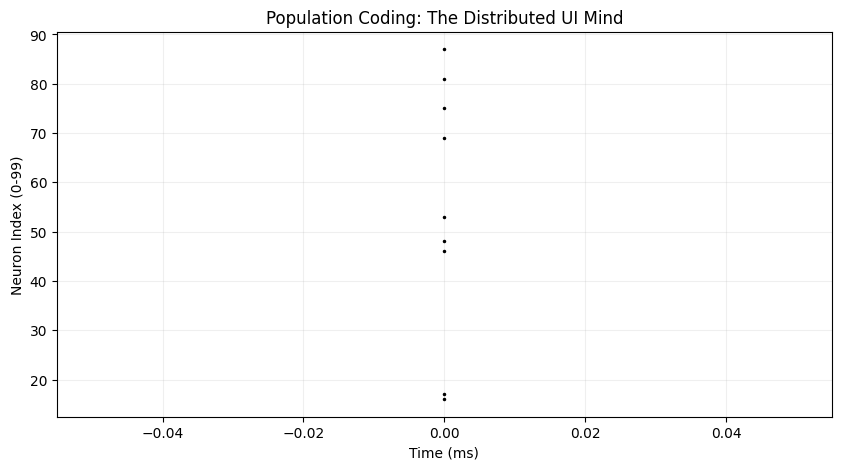

In [24]:
start_scope()

# 1. Rules: Standard biology
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. The Population (100 neurons)
P = NeuronGroup(100, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=2*ms, method='exact')

# 3. RANDOM WIRING
# Each neuron has a 10% chance of connecting to any other neuron
S = Synapses(P, P, on_pre='v_post += 5*mV')
S.connect(p=0.1) 

# 4. THE EXTERNAL STIMULUS
# We "shock" 10 random neurons to start a cascade of activity
P.v = -70*mV
P.v[np.random.randint(0, 100, 10)] = -49*mV

# 5. Record the whole "Brain"
spikemon = SpikeMonitor(P)
run(200*ms)

# 6. Plot the Raster (The "Scan" view)
plt.figure(figsize=(10, 5))
plt.plot(spikemon.t/ms, spikemon.i, '.k', markersize=3)
plt.title('Population Coding: The Distributed UI Mind')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index (0-99)')
plt.grid(True, alpha=0.2)
plt.show()

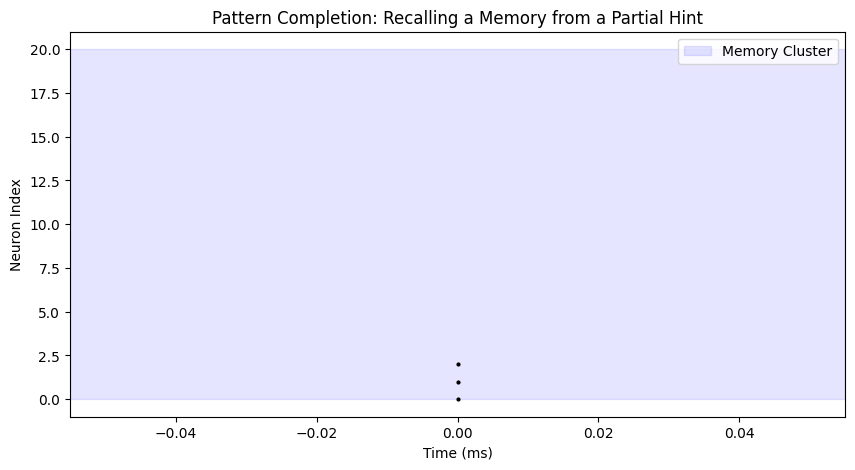

In [25]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. The Population (100 Neurons)
P = NeuronGroup(100, eqs, threshold='v > -50*mV', reset='v = -70*mV', 
                refractory=2*ms, method='exact')

# 3. WIRING THE "MEMORY CLUSTER"
# We connect neurons 0 through 20 to each other very strongly
S = Synapses(P, P, on_pre='v_post += 8*mV')
S.connect(i=range(21), j=range(21)) # Internal cluster wiring

# Add some random background noise so the brain stays "alive"
S_noise = Synapses(P, P, on_pre='v_post += 1*mV')
S_noise.connect(p=0.05)

# 4. THE TEST: Partial Trigger
P.v = -70*mV
# We only trigger neurons 0, 1, and 2 (the "hint" of the memory)
P.v[0:3] = -49*mV 

# 5. Run and Record
spikemon = SpikeMonitor(P)
run(100*ms)

# 6. Plot the "Recall"
plt.figure(figsize=(10, 5))
plt.plot(spikemon.t/ms, spikemon.i, '.k', markersize=4)
plt.axhspan(0, 20, color='blue', alpha=0.1, label='Memory Cluster')
plt.title('Pattern Completion: Recalling a Memory from a Partial Hint')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.legend()
plt.show()

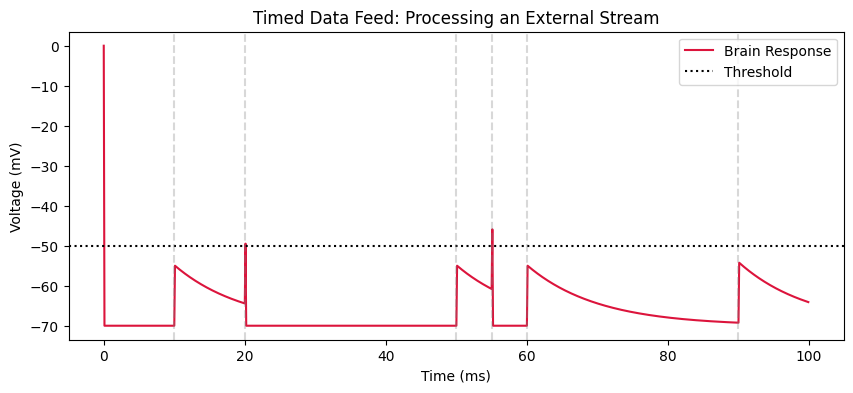

In [26]:
start_scope()

# 1. Define the Schedule (The "Data Feed")
# The neuron will spike at these specific times (in ms)
stimulus_times = [10, 20, 50, 55, 60, 90] * ms
input_indices = [0, 0, 0, 0, 0, 0] # Which neuron in the input group fires

# 2. Create the Input Generator
# This acts like the "Eyes" or "Ears" of the UI
P = SpikeGeneratorGroup(1, input_indices, stimulus_times)

# 3. Create the "Processing" Neuron
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt'
G = NeuronGroup(1, eqs, threshold='v > -50*mV', reset='v = -70*mV', method='exact')

# 4. Connect the Feed to the Brain
S = Synapses(P, G, on_pre='v_post += 15*mV')
S.connect()

# 5. Record and Run
M = StateMonitor(G, 'v', record=True)
run(100*ms)

# 6. Plot the Response to the Stream
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Brain Response', color='crimson')
plt.axhline(-50, ls=':', c='k', label='Threshold')
# Mark the input times with gray lines
for t in stimulus_times:
    plt.axvline(t/ms, color='gray', alpha=0.3, linestyle='--')

plt.title('Timed Data Feed: Processing an External Stream')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

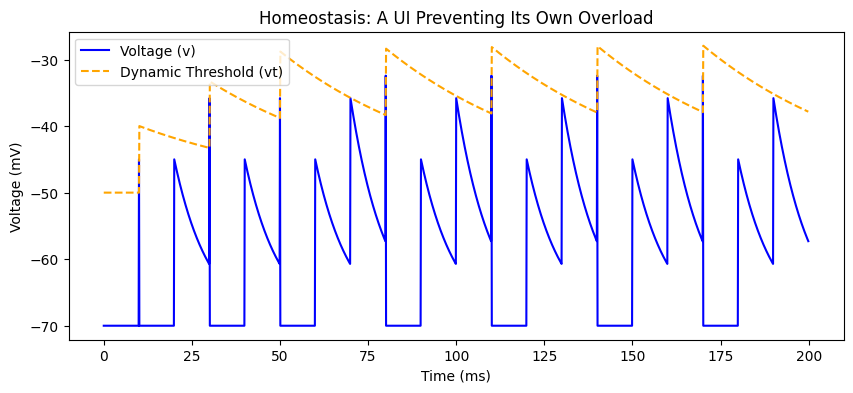

In [28]:
start_scope()

# 1. Rules with an Adaptive Threshold (vt)
# vt decays back to the base level of -50mV over time
tau = 10*ms
tau_vt = 50*ms # How long the "exhaustion" lasts
eqs = '''
dv/dt = (-70*mV - v) / tau : volt
dvt/dt = (-50*mV - vt) / tau_vt : volt
'''

# 2. Create the Neuron
# The threshold is now a variable (vt) instead of a fixed number
G = NeuronGroup(1, eqs, threshold='v > vt', reset='v = -70*mV; vt += 10*mV', method='exact')

# 3. CONSTANT INPUT
# We apply a steady "pressure" that would normally make it fire forever
G.v = -70*mV
G.vt = -50*mV
# Using a StateMonitor to watch the "Exhaustion" (vt)
M = StateMonitor(G, ['v', 'vt'], record=True)

# 4. Simulate a constant "Data Overload"
# We'll just force the voltage up every few ms to simulate heavy traffic
for _ in range(20):
    run(10*ms)
    G.v += 25*mV 

# 5. Plot the Self-Regulation
plt.figure(figsize=(10, 4))
plt.plot(M.t/ms, M.v[0]/mV, label='Voltage (v)', color='blue')
plt.plot(M.t/ms, M.v[0]/mV * 0 + M.vt[0]/mV, label='Dynamic Threshold (vt)', color='orange', linestyle='--')
plt.title('Homeostasis: A UI Preventing Its Own Overload')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

WARNING    Model equations use the "unless refractory" flag but no refractory keyword was given. [brian2.groups.neurongroup.no_refractory]
WARNING    Model equations use the "unless refractory" flag but no refractory keyword was given. [brian2.groups.neurongroup.no_refractory]
WARNING    Model equations use the "unless refractory" flag but no refractory keyword was given. [brian2.groups.neurongroup.no_refractory]
INFO       No numerical integration method specified for group 'Hidden_Layer', using method 'exact' (took 0.02s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Input_Layer', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Output_Layer', using method 'exact' (took 0.02s). [brian2.stateupdaters.base.method_choice]


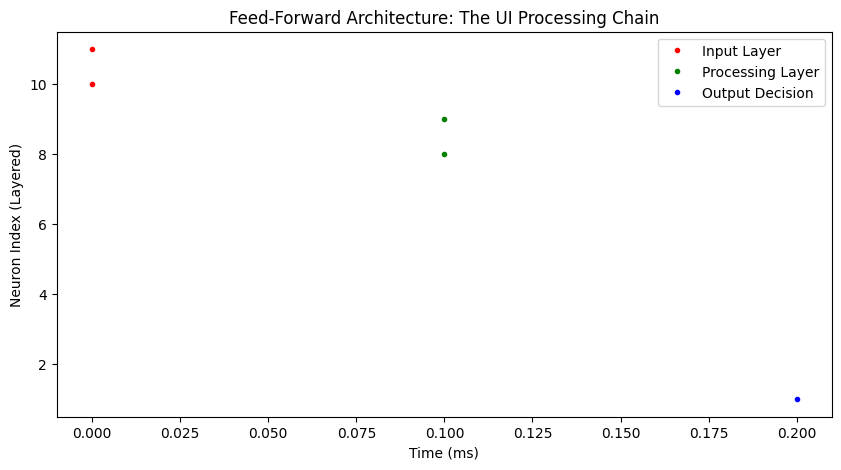

In [29]:
start_scope()

# 1. Physics
eqs = 'dv/dt = (-70*mV - v) / (10*ms) : volt (unless refractory)'

# 2. Create the Layers
L1 = NeuronGroup(5, eqs, threshold='v > -50*mV', reset='v = -70*mV', name='Input_Layer')
L2 = NeuronGroup(5, eqs, threshold='v > -50*mV', reset='v = -70*mV', name='Hidden_Layer')
L3 = NeuronGroup(2, eqs, threshold='v > -50*mV', reset='v = -70*mV', name='Output_Layer')

# 3. LAYER CONNECTIONS (The Flow)
# Layer 1 talks to Layer 2
S1 = Synapses(L1, L2, on_pre='v_post += 15*mV')
S1.connect(p=0.6) # 60% chance of connecting between layers

# Layer 2 talks to Layer 3
S2 = Synapses(L2, L3, on_pre='v_post += 15*mV')
S2.connect(p=0.6)

# 4. STIMULATE THE INPUT
L1.v = -70*mV
L2.v = -70*mV
L3.v = -70*mV
L1.v[0:2] = -49*mV # Poke the first two input neurons

# 5. Record the Flow
spikemon = SpikeMonitor(L1, name='mon1')
spikemon2 = SpikeMonitor(L2, name='mon2')
spikemon3 = SpikeMonitor(L3, name='mon3')

run(50*ms)

# 6. Plot the "Thought Process"
plt.figure(figsize=(10, 5))
plt.plot(spikemon.t/ms, spikemon.i + 10, '.r', label='Input Layer')
plt.plot(spikemon2.t/ms, spikemon2.i + 5, '.g', label='Processing Layer')
plt.plot(spikemon3.t/ms, spikemon3.i, '.b', label='Output Decision')
plt.title('Feed-Forward Architecture: The UI Processing Chain')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index (Layered)')
plt.legend()
plt.show()